INFORMACIÓN DEL DATASET
Dimensiones: (3654, 165)

Primeros registros:
       DATE  MONTH  BASEL_cloud_cover  BASEL_humidity  BASEL_pressure  \
0  20000101      1                  8            0.89          1.0286   
1  20000102      1                  8            0.87          1.0318   
2  20000103      1                  5            0.81          1.0314   
3  20000104      1                  7            0.79          1.0262   
4  20000105      1                  5            0.90          1.0246   

   BASEL_global_radiation  BASEL_precipitation  BASEL_sunshine  \
0                    0.20                 0.03             0.0   
1                    0.25                 0.00             0.0   
2                    0.50                 0.00             3.7   
3                    0.63                 0.35             6.9   
4                    0.51                 0.07             3.7   

   BASEL_temp_mean  BASEL_temp_min  ...  STOCKHOLM_temp_min  \
0              2.9             

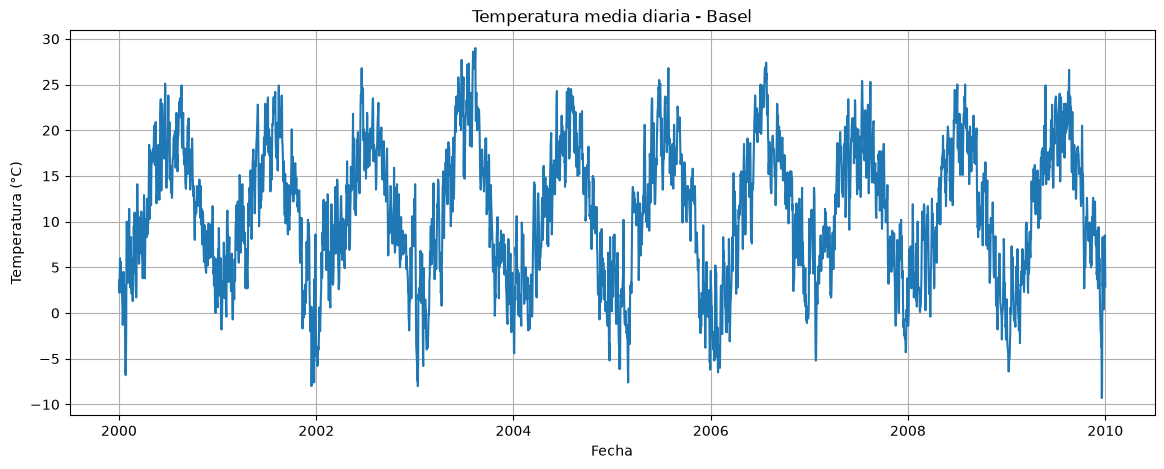

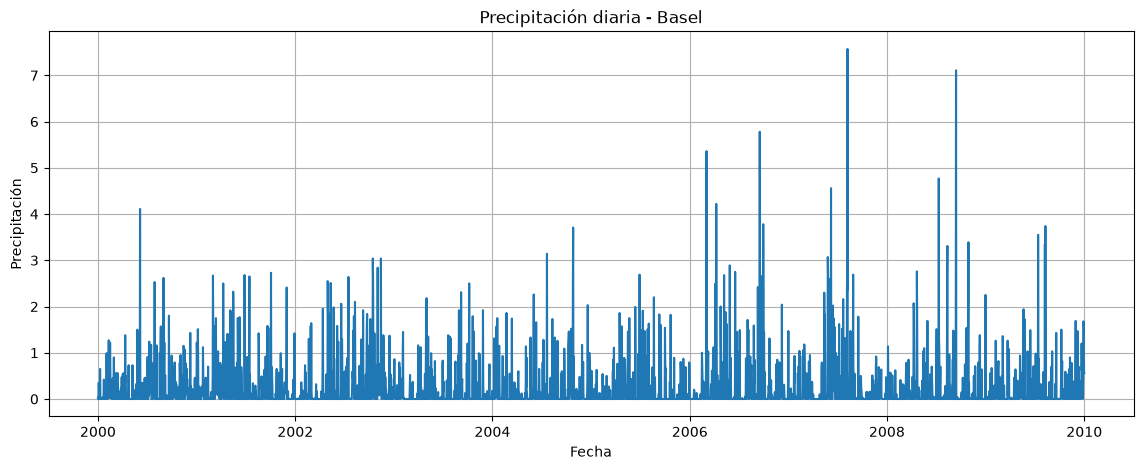


NORMALIZACIÓN
Media: 11.022796934865902
Desviación estándar: 7.413739132098481

VENTANAS DE TEMPERATURA
X: (3649, 5)
Y: (3649,)

Datos de entrenamiento: 2919
Datos de prueba: 730
Temperatura - Época 0: Error = 0.958145
Temperatura - Época 100: Error = 0.265659
Temperatura - Época 200: Error = 0.148546
Temperatura - Época 300: Error = 0.139540
Temperatura - Época 400: Error = 0.133005
Temperatura - Época 500: Error = 0.126892
Temperatura - Época 600: Error = 0.121260
Temperatura - Época 700: Error = 0.116177
Temperatura - Época 800: Error = 0.111683
Temperatura - Época 900: Error = 0.107782


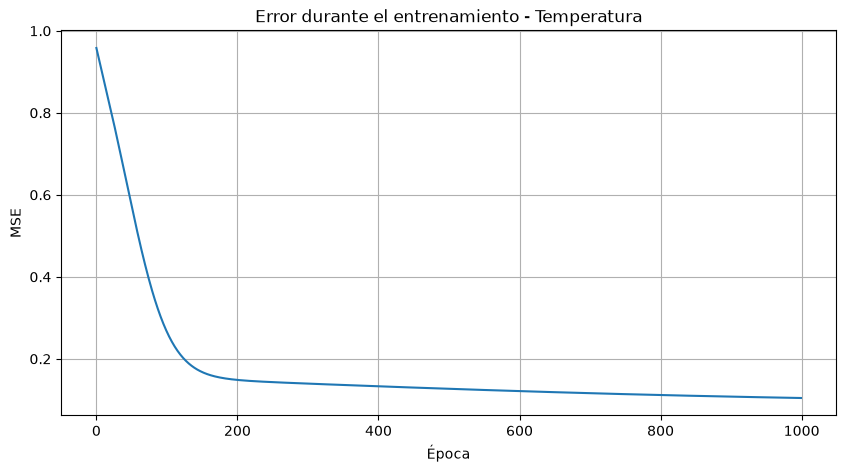


RESULTADOS DEL MODELO DE TEMPERATURA
MSE  : 5.2192
RMSE : 2.2845
MAE  : 1.8246


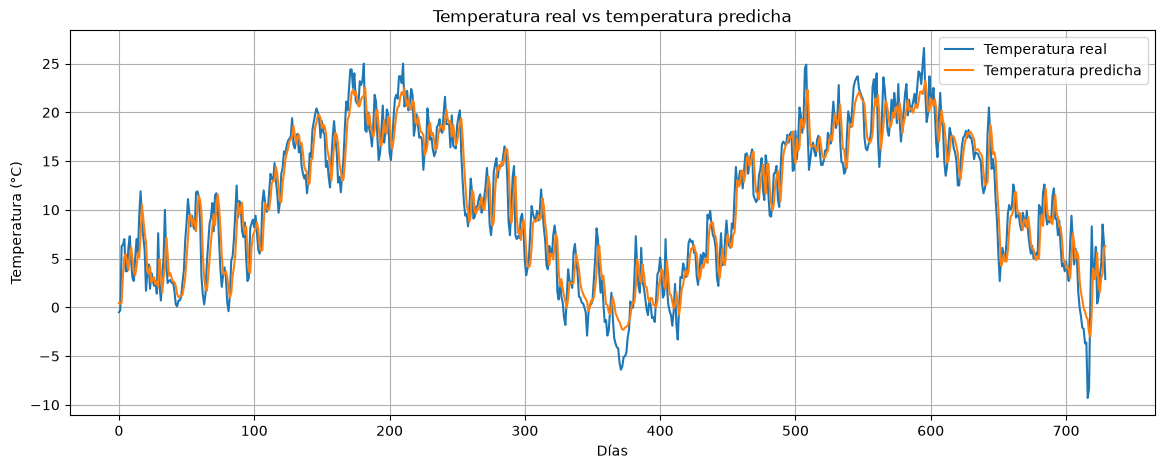


DATOS DE LLUVIA
Entrenamiento: 2919
Prueba: 730
Lluvia - Época 0: Error = 0.249241
Lluvia - Época 100: Error = 0.248146
Lluvia - Época 200: Error = 0.247205
Lluvia - Época 300: Error = 0.246326
Lluvia - Época 400: Error = 0.245450
Lluvia - Época 500: Error = 0.244539
Lluvia - Época 600: Error = 0.243564
Lluvia - Época 700: Error = 0.242508
Lluvia - Época 800: Error = 0.241358
Lluvia - Época 900: Error = 0.240111
Lluvia - Época 1000: Error = 0.238765
Lluvia - Época 1100: Error = 0.237326
Lluvia - Época 1200: Error = 0.235805
Lluvia - Época 1300: Error = 0.234217
Lluvia - Época 1400: Error = 0.232582
Lluvia - Época 1500: Error = 0.230922
Lluvia - Época 1600: Error = 0.229263
Lluvia - Época 1700: Error = 0.227632
Lluvia - Época 1800: Error = 0.226053
Lluvia - Época 1900: Error = 0.224550
Lluvia - Época 2000: Error = 0.223141
Lluvia - Época 2100: Error = 0.221844
Lluvia - Época 2200: Error = 0.220666
Lluvia - Época 2300: Error = 0.219612
Lluvia - Época 2400: Error = 0.218681
Lluvia - Époc

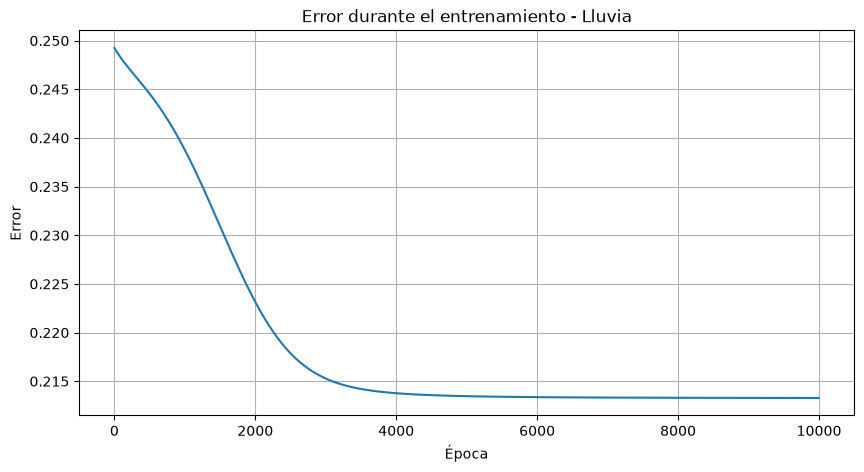


RESULTADOS DEL MODELO DE LLUVIA
Accuracy: 67.53%

Matriz de confusión:
Verdaderos negativos: 262
Falsos positivos: 118
Falsos negativos: 119
Verdaderos positivos: 231


PRONÓSTICO DE LOS PRÓXIMOS 5 DÍAS
     Fecha  Temperatura pronosticada (°C)  Probabilidad de lluvia Pronóstico lluvia
2010-01-02                           3.83                   66.86            LLUEVE
2010-01-03                           3.99                   66.86            LLUEVE
2010-01-04                           4.10                   66.86            LLUEVE
2010-01-05                           3.71                   66.86            LLUEVE
2010-01-06                           3.64                   66.86            LLUEVE


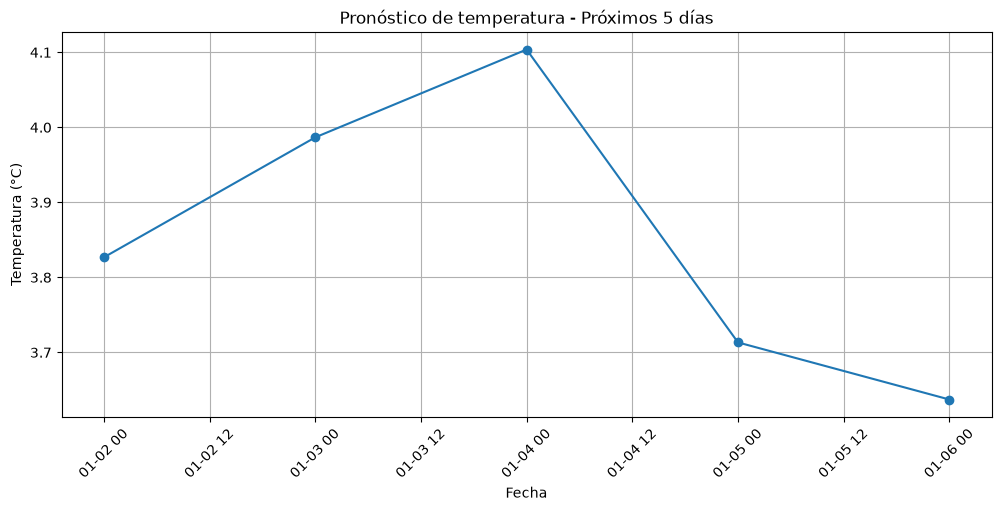

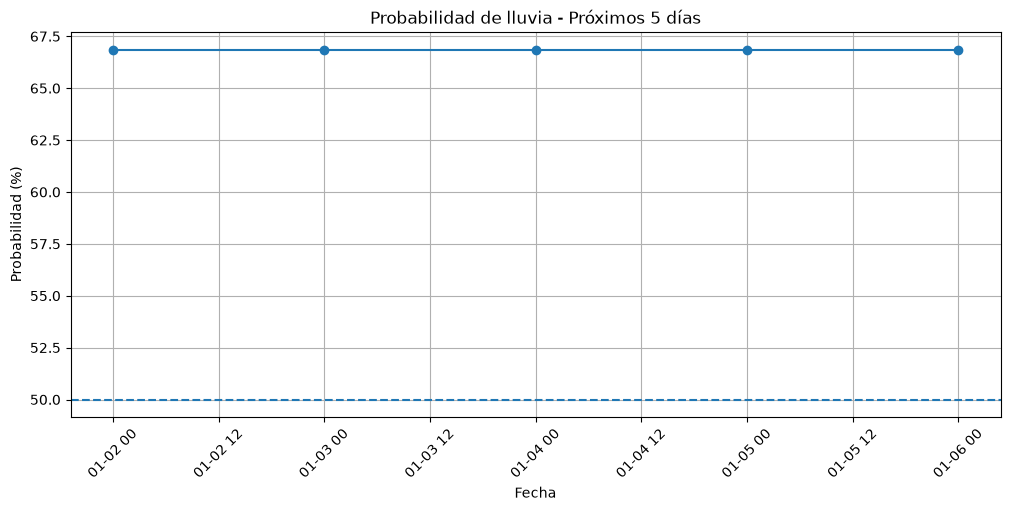



RESUMEN DEL PRONÓSTICO
2010-01-02 | 3.83 °C | 66.86% | LLUEVE
2010-01-03 | 3.99 °C | 66.86% | LLUEVE
2010-01-04 | 4.10 °C | 66.86% | LLUEVE
2010-01-05 | 3.71 °C | 66.86% | LLUEVE
2010-01-06 | 3.64 °C | 66.86% | LLUEVE


DISJ


In [6]:
# PRONÓSTICO CLIMÁTICO CON REDES NEURONALES
# Temperatura y Pronóstico de lluvia

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/florian-huber/weather_prediction_dataset/refs/heads/main/dataset/weather_prediction_dataset.csv"

df = pd.read_csv(url)

print("==============================================")
print("INFORMACIÓN DEL DATASET")
print("==============================================")

print("Dimensiones:", df.shape)

print("\nPrimeros registros:")
print(df.head())

print("\nColumnas disponibles:")
print(df.columns.tolist())

df["DATE"] = pd.to_datetime(
    df["DATE"].astype(str),
    format="%Y%m%d"
)

df = df.sort_values("DATE").reset_index(drop=True)

temperatura = df["BASEL_temp_mean"].values.astype(float)

# Precipitación de Basel
precipitacion = df["BASEL_precipitation"].values.astype(float)

fechas = df["DATE"].values


print("\n==============================================")
print("VARIABLES SELECCIONADAS")
print("==============================================")

print("Temperatura: BASEL_temp_mean")
print("Precipitación: BASEL_precipitation")

# Si la precipitación es mayor que 0:
# 1 = LLUEVE
# 0 = NO LLUEVE

lluvia = (precipitacion > 0).astype(int)


print("\n==============================================")
print("DISTRIBUCIÓN DE LLUVIA")
print("==============================================")

print(
    "Días sin lluvia:",
    np.sum(lluvia == 0)
)

print(
    "Días con lluvia:",
    np.sum(lluvia == 1)
)

plt.figure(figsize=(14, 5))

plt.plot(
    fechas,
    temperatura
)

plt.title(
    "Temperatura media diaria - Basel"
)

plt.xlabel("Fecha")

plt.ylabel(
    "Temperatura (°C)"
)

plt.grid(True)

plt.show()

plt.figure(figsize=(14, 5))

plt.plot(
    fechas,
    precipitacion
)

plt.title(
    "Precipitación diaria - Basel"
)

plt.xlabel("Fecha")

plt.ylabel(
    "Precipitación"
)

plt.grid(True)

plt.show()

media_temp = np.mean(temperatura)

desviacion_temp = np.std(temperatura)

temperatura_normalizada = (
    temperatura - media_temp
) / desviacion_temp


print("\n==============================================")
print("NORMALIZACIÓN")
print("==============================================")

print(
    "Media:",
    media_temp
)

print(
    "Desviación estándar:",
    desviacion_temp
)

ventana = 5

X_temp = []

Y_temp = []


for i in range(
    len(temperatura_normalizada) - ventana
):

    X_temp.append(
        temperatura_normalizada[
            i:i + ventana
        ]
    )

    Y_temp.append(
        temperatura_normalizada[
            i + ventana
        ]
    )


X_temp = np.array(X_temp)

Y_temp = np.array(Y_temp)


print("\n==============================================")
print("VENTANAS DE TEMPERATURA")
print("==============================================")

print(
    "X:",
    X_temp.shape
)

print(
    "Y:",
    Y_temp.shape
)

porcentaje_entrenamiento = 0.8

limite_temp = int(
    len(X_temp) *
    porcentaje_entrenamiento
)


X_temp_train = X_temp[
    :limite_temp
]

Y_temp_train = Y_temp[
    :limite_temp
]


X_temp_test = X_temp[
    limite_temp:
]

Y_temp_test = Y_temp[
    limite_temp:
]


print(
    "\nDatos de entrenamiento:",
    len(X_temp_train)
)

print(
    "Datos de prueba:",
    len(X_temp_test)
)


np.random.seed(42)

entradas = ventana

neuronas_ocultas = 8


W1_temp = (
    np.random.randn(
        entradas,
        neuronas_ocultas
    ) * 0.1
)

b1_temp = np.zeros(
    (1, neuronas_ocultas)
)


W2_temp = (
    np.random.randn(
        neuronas_ocultas,
        1
    ) * 0.1
)

b2_temp = np.zeros(
    (1, 1)
)

def tanh(x):

    return np.tanh(x)


def derivada_tanh(x):

    return 1 - np.tanh(x) ** 2

tasa_aprendizaje = 0.01

epocas = 1000

errores_temp = []


for epoca in range(epocas):

    Z1 = np.dot(
        X_temp_train,
        W1_temp
    ) + b1_temp
    A1 = tanh(Z1)

    Z2 = np.dot(
        A1,
        W2_temp
    ) + b2_temp

    Y_pred = Z2

    error = (
        Y_pred -
        Y_temp_train.reshape(-1, 1)
    )


    perdida = np.mean(
        error ** 2
    )


    errores_temp.append(
        perdida
    )

    dZ2 = error


    dW2 = np.dot(
        A1.T,
        dZ2
    ) / len(X_temp_train)


    db2 = np.mean(
        dZ2,
        axis=0,
        keepdims=True
    )


    dA1 = np.dot(
        dZ2,
        W2_temp.T
    )


    dZ1 = (
        dA1 *
        derivada_tanh(Z1)
    )


    dW1 = np.dot(
        X_temp_train.T,
        dZ1
    ) / len(X_temp_train)


    db1 = np.mean(
        dZ1,
        axis=0,
        keepdims=True
    )

    W2_temp -= (
        tasa_aprendizaje *
        dW2
    )


    b2_temp -= (
        tasa_aprendizaje *
        db2
    )


    W1_temp -= (
        tasa_aprendizaje *
        dW1
    )


    b1_temp -= (
        tasa_aprendizaje *
        db1
    )

    if epoca % 100 == 0:

        print(
            f"Temperatura - "
            f"Época {epoca}: "
            f"Error = {perdida:.6f}"
        )

plt.figure(figsize=(10, 5))

plt.plot(
    errores_temp
)

plt.title(
    "Error durante el entrenamiento - Temperatura"
)

plt.xlabel("Época")

plt.ylabel("MSE")

plt.grid(True)

plt.show()

Z1_test = np.dot(
    X_temp_test,
    W1_temp
) + b1_temp


A1_test = tanh(
    Z1_test
)


Z2_test = np.dot(
    A1_test,
    W2_temp
) + b2_temp


predicciones_temp_normalizadas = (
    Z2_test.flatten()
)

predicciones_temp = (
    predicciones_temp_normalizadas *
    desviacion_temp
) + media_temp


valores_reales_temp = (
    Y_temp_test *
    desviacion_temp
) + media_temp

mse_temp = np.mean(
    (
        valores_reales_temp -
        predicciones_temp
    ) ** 2
)


rmse_temp = np.sqrt(
    mse_temp
)


mae_temp = np.mean(
    np.abs(
        valores_reales_temp -
        predicciones_temp
    )
)


print("\n==============================================")
print("RESULTADOS DEL MODELO DE TEMPERATURA")
print("==============================================")


print(
    f"MSE  : {mse_temp:.4f}"
)

print(
    f"RMSE : {rmse_temp:.4f}"
)

print(
    f"MAE  : {mae_temp:.4f}"
)

plt.figure(figsize=(14, 5))

plt.plot(
    valores_reales_temp,
    label="Temperatura real"
)

plt.plot(
    predicciones_temp,
    label="Temperatura predicha"
)

plt.title(
    "Temperatura real vs temperatura predicha"
)

plt.xlabel("Días")

plt.ylabel(
    "Temperatura (°C)"
)

plt.legend()

plt.grid(True)

plt.show()

X_lluvia = []

Y_lluvia = []


for i in range(
    len(lluvia) - ventana
):

    X_lluvia.append(
        lluvia[
            i:i + ventana
        ]
    )

    Y_lluvia.append(
        lluvia[
            i + ventana
        ]
    )


X_lluvia = np.array(
    X_lluvia
)

Y_lluvia = np.array(
    Y_lluvia
)

limite_lluvia = int(
    len(X_lluvia) *
    porcentaje_entrenamiento
)


X_lluvia_train = X_lluvia[
    :limite_lluvia
]

Y_lluvia_train = Y_lluvia[
    :limite_lluvia
]


X_lluvia_test = X_lluvia[
    limite_lluvia:
]

Y_lluvia_test = Y_lluvia[
    limite_lluvia:
]


print("\n==============================================")
print("DATOS DE LLUVIA")
print("==============================================")

print(
    "Entrenamiento:",
    len(X_lluvia_train)
)

print(
    "Prueba:",
    len(X_lluvia_test)
)

np.random.seed(42)


W1_lluvia = (
    np.random.randn(
        entradas,
        neuronas_ocultas
    ) * 0.1
)


b1_lluvia = np.zeros(
    (1, neuronas_ocultas)
)

W2_lluvia = (
    np.random.randn(
        neuronas_ocultas,
        1
    ) * 0.1
)

b2_lluvia = np.zeros(
    (1, 1)
)

def sigmoid(x):

    return 1 / (
        1 + np.exp(-np.clip(x, -500, 500))
    )

tasa_aprendizaje_lluvia = 0.01

epocas_lluvia = 10000

errores_lluvia = []


for epoca in range(
    epocas_lluvia
):

    Z1 = np.dot(
        X_lluvia_train,
        W1_lluvia
    ) + b1_lluvia


    A1 = tanh(Z1)


    Z2 = np.dot(
        A1,
        W2_lluvia
    ) + b2_lluvia


    Y_pred = sigmoid(Z2)

    error = (
        Y_pred -
        Y_lluvia_train.reshape(-1, 1)
    )


    perdida = np.mean(
        error ** 2
    )


    errores_lluvia.append(
        perdida
    )

    dZ2 = error

    dW2 = np.dot(
        A1.T,
        dZ2
    ) / len(X_lluvia_train)


    db2 = np.mean(
        dZ2,
        axis=0,
        keepdims=True
    )


    dA1 = np.dot(
        dZ2,
        W2_lluvia.T
    )


    dZ1 = (
        dA1 *
        derivada_tanh(Z1)
    )


    dW1 = np.dot(
        X_lluvia_train.T,
        dZ1
    ) / len(X_lluvia_train)


    db1 = np.mean(
        dZ1,
        axis=0,
        keepdims=True
    )

    W2_lluvia -= (
        tasa_aprendizaje_lluvia *
        dW2
    )


    b2_lluvia -= (
        tasa_aprendizaje_lluvia *
        db2
    )


    W1_lluvia -= (
        tasa_aprendizaje_lluvia *
        dW1
    )


    b1_lluvia -= (
        tasa_aprendizaje_lluvia *
        db1
    )


    if epoca % 100 == 0:

        print(
            f"Lluvia - "
            f"Época {epoca}: "
            f"Error = {perdida:.6f}"
        )

plt.figure(figsize=(10, 5))

plt.plot(
    errores_lluvia
)

plt.title(
    "Error durante el entrenamiento - Lluvia"
)

plt.xlabel("Época")

plt.ylabel("Error")

plt.grid(True)

plt.show()

Z1_test_lluvia = np.dot(
    X_lluvia_test,
    W1_lluvia
) + b1_lluvia


A1_test_lluvia = tanh(
    Z1_test_lluvia
)


Z2_test_lluvia = np.dot(
    A1_test_lluvia,
    W2_lluvia
) + b2_lluvia


probabilidades_lluvia = sigmoid(
    Z2_test_lluvia
).flatten()

predicciones_lluvia = (
    probabilidades_lluvia >= 0.5
).astype(int)

accuracy = np.mean(
    predicciones_lluvia ==
    Y_lluvia_test
)


print("\n==============================================")
print("RESULTADOS DEL MODELO DE LLUVIA")
print("==============================================")


print(
    f"Accuracy: {accuracy * 100:.2f}%"
)

verdaderos_positivos = np.sum(
    (Y_lluvia_test == 1) &
    (predicciones_lluvia == 1)
)


verdaderos_negativos = np.sum(
    (Y_lluvia_test == 0) &
    (predicciones_lluvia == 0)
)


falsos_positivos = np.sum(
    (Y_lluvia_test == 0) &
    (predicciones_lluvia == 1)
)


falsos_negativos = np.sum(
    (Y_lluvia_test == 1) &
    (predicciones_lluvia == 0)
)


print("\nMatriz de confusión:")

print(
    "Verdaderos negativos:",
    verdaderos_negativos
)

print(
    "Falsos positivos:",
    falsos_positivos
)

print(
    "Falsos negativos:",
    falsos_negativos
)

print(
    "Verdaderos positivos:",
    verdaderos_positivos
)

print("\n")
print("==============================================")
print("PRONÓSTICO DE LOS PRÓXIMOS 5 DÍAS")
print("==============================================")

entrada_temp = temperatura_normalizada[
    -ventana:
].copy()

entrada_lluvia = lluvia[
    -ventana:
].copy()

pronosticos_temperatura = []

pronosticos_lluvia = []

probabilidades = []

for dia in range(5):

    X_actual_temp = entrada_temp.reshape(
        1,
        ventana
    )

    Z1 = np.dot(
        X_actual_temp,
        W1_temp
    ) + b1_temp

    A1 = tanh(Z1)

    Z2 = np.dot(
        A1,
        W2_temp
    ) + b2_temp

    pred_temp_normalizada = (
        Z2[0, 0]
    )

    pred_temp = (
        pred_temp_normalizada *
        desviacion_temp
    ) + media_temp

    pronosticos_temperatura.append(
        pred_temp
    )

    entrada_temp = np.append(
        entrada_temp[1:],
        pred_temp_normalizada
    )

    X_actual_lluvia = entrada_lluvia.reshape(
        1,
        ventana
    )

    Z1 = np.dot(
        X_actual_lluvia,
        W1_lluvia
    ) + b1_lluvia

    A1 = tanh(Z1)

    Z2 = np.dot(
        A1,
        W2_lluvia
    ) + b2_lluvia

    probabilidad = sigmoid(
        Z2
    )[0, 0]

    probabilidades.append(
        probabilidad
    )

    if probabilidad >= 0.5:

        pred_lluvia = 1

    else:

        pred_lluvia = 0

    pronosticos_lluvia.append(
        pred_lluvia
    )


    # Agregar predicción a la ventana
    entrada_lluvia = np.append(
        entrada_lluvia[1:],
        pred_lluvia
    )

ultima_fecha = df["DATE"].iloc[-1]

fechas_pronostico = pd.date_range(
    start=ultima_fecha + pd.Timedelta(days=1),
    periods=5,
    freq="D"
)

resultado = pd.DataFrame({

    "Fecha":
        fechas_pronostico,

    "Temperatura pronosticada (°C)":
        np.round(
            pronosticos_temperatura,
            2
        ),

    "Probabilidad de lluvia":
        np.round(
            np.array(probabilidades) * 100,
            2
        ),

    "Pronóstico lluvia":
        [
            "LLUEVE"
            if x == 1
            else "NO LLUEVE"
            for x in pronosticos_lluvia
        ]

})


print(
    resultado.to_string(
        index=False
    )
)

plt.figure(figsize=(12, 5))

plt.plot(
    fechas_pronostico,
    pronosticos_temperatura,
    marker="o"
)

plt.title(
    "Pronóstico de temperatura - Próximos 5 días"
)

plt.xlabel("Fecha")

plt.ylabel("Temperatura (°C)")

plt.grid(True)

plt.xticks(rotation=45)

plt.show()

plt.figure(figsize=(12, 5))

plt.plot(
    fechas_pronostico,
    np.array(probabilidades) * 100,
    marker="o"
)

plt.axhline(50,linestyle="--")

plt.title("Probabilidad de lluvia - Próximos 5 días")

plt.xlabel("Fecha")

plt.ylabel("Probabilidad (%)")

plt.grid(True)

plt.xticks(rotation=45)

plt.show()

print("\n")
print("==============================================")
print("RESUMEN DEL PRONÓSTICO")
print("==============================================")

for i in range(5):

    print(
        f"{fechas_pronostico[i].strftime('%Y-%m-%d')} | "
        f"{pronosticos_temperatura[i]:.2f} °C | "
        f"{probabilidades[i] * 100:.2f}% | "
        f"{'LLUEVE' if pronosticos_lluvia[i] == 1 else 'NO LLUEVE'}"
    )


print("\n")
print("DISJ")